# Basic Visualisation
In this chapter, we will have a basic visualisation of the data we just downloaded. The idea is to 
- Load and prepare the data once
- Reuse shared objects like borders
- Understand basic visualisation

Urban climate data (such as temperature, air quality, or cooling capacity) often contains many cities, years, and variables. Raw tables alone make it difficult to understand patterns or differences quickly. Visualisation helps transform complex data into clear insights that are easier to interpret and communicate.

Why visualisation matters

- Reveals trends over time (e.g., rising urban temperatures)
- Shows spatial patterns (e.g., hotter city centers vs. greener outskirts)
- Makes comparisons between cities or regions easier
  
Helps detect outliers or unusual values

When to use : Tables vs. Plots

- Tables are best for checking exact numbers and verifying data
- Plots are best for identifying patterns, trends, and relationships
- Use tables for precision, plots for understanding

Common beginner mistakes

- Plotting too many variables in one chart
- Ignoring time scale (daily vs. yearly data)
- Missing axis labels or units
- Using misleading scales
- Overcrowding maps with too many labels

Clear, focused, and transparent visualisations are essential in urban climate analysis, especially when results inform planning and policy decisions.

# Visualising urban climate data from a GeoPackage (.gpkg)
We assume the GeoPackage contains:
- a geometry column
- a numeric climate variable
- optionally a time or city identifier

# Load and prepare the data 
This cell loads the spatial dataset and prepares it for visualisation. We inspect the data structure, select the variable of interest, and ensure it is in the correct numeric format. We also create shared elements, such as city and country borders, that will be reused in later visualisations.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as pe

# Load the GeoPackage
gdf = gpd.read_file("../../00_data/downloaded_data/climate_regulation_in_cities.gpkg")

# Inspect the data
print(gdf.head())
print("Columns:", list(gdf.columns))

# Select the variable to visualize
value_col = "Pop_Benefit_Percent"
name_col = "GEN"

# Check that the required columns exist
if value_col not in gdf.columns:
    raise ValueError(f"Column '{value_col}' not found. Available columns: {list(gdf.columns)}")
if name_col not in gdf.columns:
    raise ValueError(f"Column '{name_col}' not found. Available columns: {list(gdf.columns)}")

# Ensure the selected variable is numeric
gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")

# Shared border layers
city_borders = gdf.boundary
country_outline = gdf.dissolve().boundary

        AGS       GEN   NUTS     Shape_Leng    Shape_Area  \
0  09563000     Fürth  DE253   49209.551437  6.334375e+07   
1  09162000   München  DE212  118084.194383  3.108342e+08   
2  09461000   Bamberg  DE241   44492.667416  5.464215e+07   
3  09262000    Passau  DE222   61360.769487  6.956591e+07   
4  09564000  Nürnberg  DE254  153997.952475  1.866370e+08   

   Pop_Benefit_Percent                                           geometry  
0            49.550707  MULTIPOLYGON (((4392577.758 2936451.016, 43926...  
1            70.270877  MULTIPOLYGON (((4432133.707 2774479.63, 443212...  
2            77.048748  MULTIPOLYGON (((4388203.406 2978639.586, 43882...  
3            78.069768  MULTIPOLYGON (((4570163.06 2838978.815, 457018...  
4            46.746620  MULTIPOLYGON (((4401927.814 2917518.273, 44019...  
Columns: ['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent', 'geometry']


# Basic Map
This is the simplest form of spatial visualisation. The map displays the selected variable using a continuous color scale, with lighter colors representing lower values and darker colors representing higher values. This provides an initial overview of how population benefit is distributed across areas.

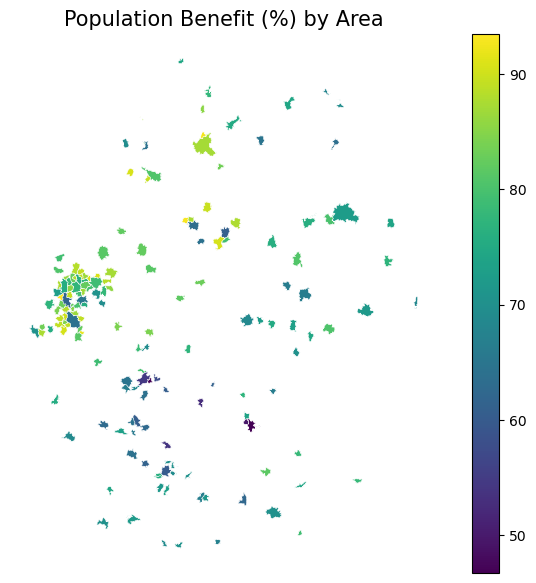

In [2]:
# Basic map
fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

ax.set_title("Population Benefit (%) by Area", fontsize=15)
ax.set_axis_off()

plt.show()

# Add all city names and borders 
This map enhances the basic map by adding spatial context. Labels allow direct identification of each city. This is useful for detailed inspection, but can quickly become cluttered.

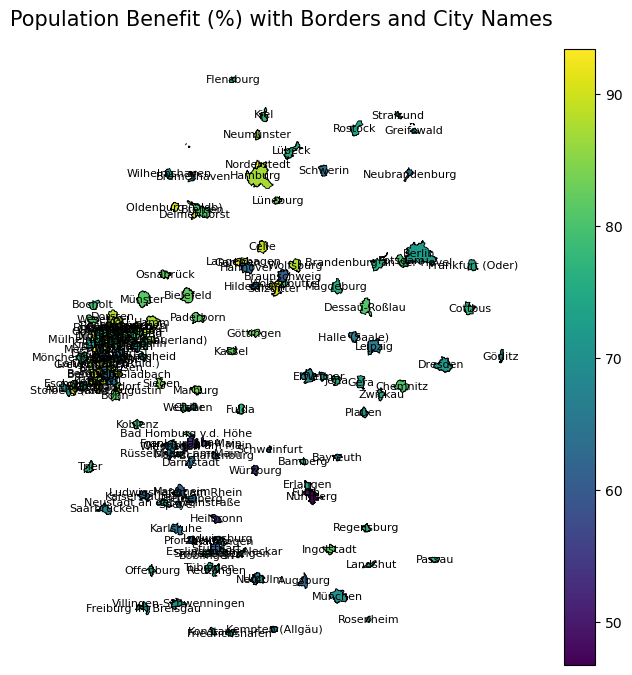

In [3]:
# Choropleth map with borders and all city labels
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# Add city borders
city_borders.plot(ax=ax, linewidth=0.6, color="black")

# Add a label inside each polygon
label_points = gdf.geometry.representative_point()

for x, y, name in zip(label_points.x, label_points.y, gdf[name_col]):
    ax.text(x, y, name, fontsize=8, ha="center", va="center")

ax.set_title("Population Benefit (%) with Borders and City Names", fontsize=15)
ax.set_axis_off()

plt.show()

# Label only selected major cities
To improve readability, this visualisation labels only a curated set of major cities. This reduces visual clutter while still providing meaningful geographic reference points. A white halo is added around the labels to ensure they remain readable on top of the colored map.

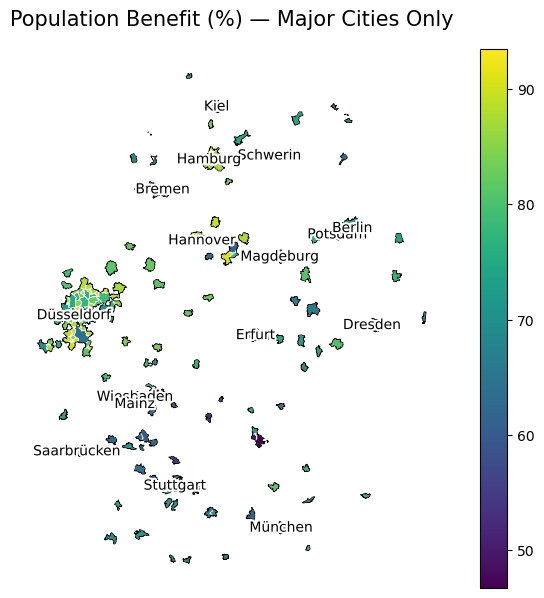

In [4]:
# Label only selected major cities to reduce clutter
major_cities = {
    "Hamburg", "Berlin", "München", "Munich", "Stuttgart", "Dresden",
    "Bremen", "Hannover", "Hanover", "Kiel", "Schwerin", "Potsdam",
    "Magdeburg", "Erfurt", "Wiesbaden", "Mainz", "Saarbrücken",
    "Saarbrucken", "Düsseldorf", "Duesseldorf"
}

# Keep only affected areas with selected names
affected = gdf[gdf[value_col].fillna(0) > 0].copy()
label_gdf = affected[affected[name_col].astype(str).isin(major_cities)].copy()

fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

city_borders.plot(ax=ax, linewidth=0.4, color="white", alpha=0.9)
country_outline.plot(ax=ax, linewidth=0.5, color="black")

# Add clean labels with a white halo
pts = label_gdf.geometry.representative_point()
for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
    txt = ax.text(
        x, y, name,
        fontsize=10,
        ha="center",
        va="center",
        color="black"
    )
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ax.set_title("Population Benefit (%) — Major Cities Only", fontsize=15)
ax.set_axis_off()

plt.show()

# Automatic labeling of top areas 
Instead of manually selecting cities, this approach automatically labels the most important areas based on size. This creates a cleaner and more scalable visualisation, especially when working with large datasets. It demonstrates how data-driven methods can improve map design.

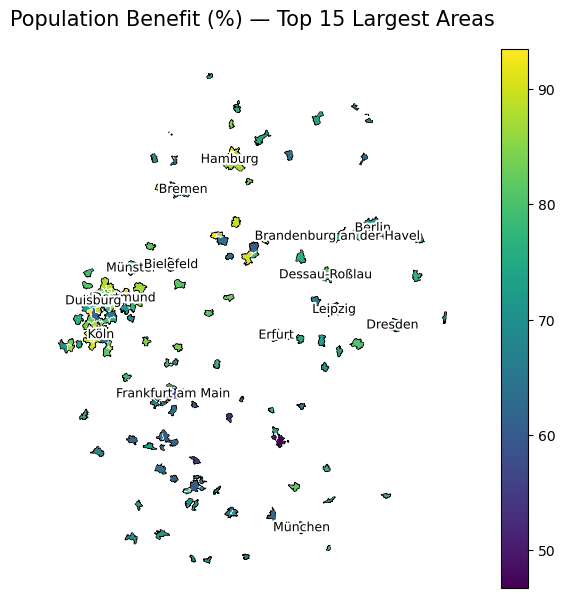

In [5]:
# Automatically label the largest areas
N_LABELS = 15

affected = gdf[gdf[value_col].fillna(0) > 0].copy()
affected["_area_m2"] = affected.geometry.area

# Select the largest polygons
label_gdf = affected.nlargest(N_LABELS, "_area_m2").copy()

fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

city_borders.plot(ax=ax, linewidth=0.4, color="white", alpha=0.9)
country_outline.plot(ax=ax, linewidth=0.5, color="black")

# Add labels with halo
pts = label_gdf.geometry.representative_point()
for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
    txt = ax.text(
        x, y, name,
        fontsize=9,
        ha="center",
        va="center",
        color="black"
    )
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ax.set_title(f"Population Benefit (%) — Top {N_LABELS} Largest Areas", fontsize=15)
ax.set_axis_off()

plt.show()

# Prepare world context
This cell prepares additional spatial context by loading a global dataset of country boundaries. The data is reprojected to a common coordinate system, and a focused map extent is created around Germany. This allows the inclusion of neighboring countries and surrounding regions in the final visualisation.

In [6]:
# Load neighboring countries for map context
world = gpd.read_file("../../00_data/downloaded_data/ne_110m_admin_0_countries.shp")

# Convert both datasets to WGS84 for consistent overlay
gdf_wgs = gdf.to_crs("EPSG:4326")
world_wgs = world.to_crs("EPSG:4326")

# Extract Germany and define a map extent around it
germany = world_wgs[world_wgs["NAME"] == "Germany"]

minx, miny, maxx, maxy = germany.total_bounds
pad_x, pad_y = 3.5, 2.5
extent = (minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y)

# Clip nearby countries to the extent
nearby = world_wgs.cx[extent[0]:extent[1], extent[2]:extent[3]]

# Rebuild borders in WGS84
city_borders_wgs = gdf_wgs.boundary
country_outline_wgs = gdf_wgs.dissolve().boundary

# Map with neighboring countries and sea labels
This final map combines all elements into a more complete and polished visualisation. It includes neighboring countries, a background representing the sea, and selected city labels. This type of map provides both local detail and broader geographic context, making it suitable for communication and presentation purposes.

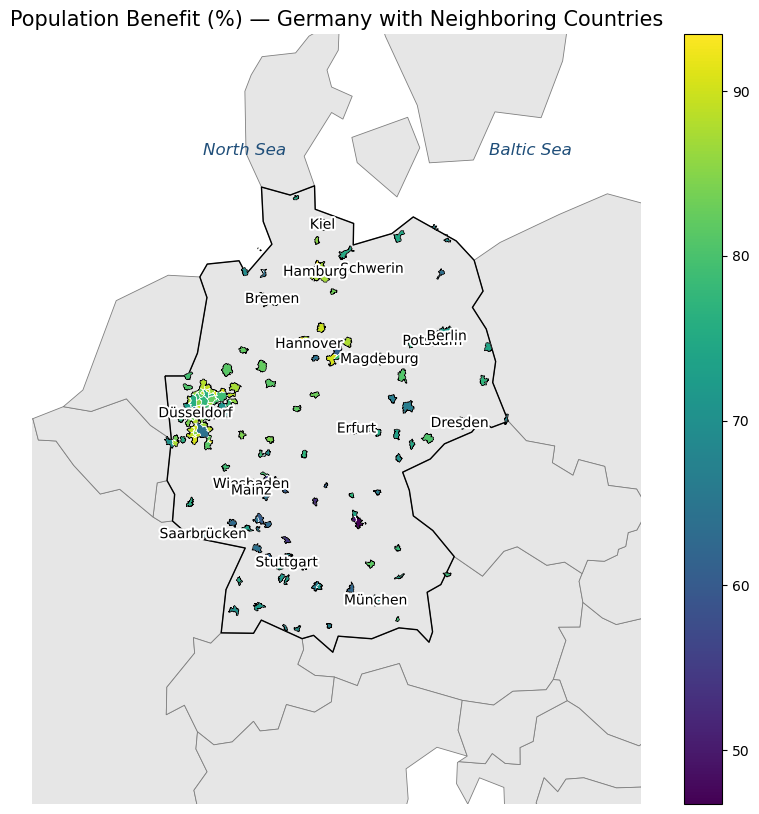

In [7]:
# Map with surrounding countries and selected city labels
major_cities = {
    "Hamburg", "Berlin", "München", "Munich", "Stuttgart",
    "Dresden", "Bremen", "Hannover", "Kiel", "Schwerin",
    "Potsdam", "Magdeburg", "Erfurt", "Wiesbaden",
    "Mainz", "Saarbrücken", "Saarbrucken", "Düsseldorf", "Duesseldorf"
}

affected = gdf_wgs[gdf_wgs[value_col].fillna(0) > 0].copy()
label_gdf = affected[affected[name_col].astype(str).isin(major_cities)].copy()

fig, ax = plt.subplots(figsize=(11, 10))

# Sea background
ax.set_facecolor("#a7d8f0")

# Neighboring countries
nearby.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#7f7f7f",
    linewidth=0.6,
    zorder=1
)

# Germany outline
germany.boundary.plot(ax=ax, color="black", linewidth=1.0, zorder=2)

# Main thematic layer
gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    zorder=3
)

# Internal and outer borders
city_borders_wgs.plot(ax=ax, linewidth=0.35, color="white", alpha=0.9, zorder=4)
country_outline_wgs.plot(ax=ax, linewidth=0.5, color="black", zorder=5)

# Add clean city labels
pts = label_gdf.geometry.representative_point()
for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
    txt = ax.text(
        x, y, name,
        fontsize=10,
        ha="center",
        va="center",
        color="black",
        zorder=10
    )
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

# Add sea labels
ax.text(7.0, 55.5, "North Sea", fontsize=12, fontstyle="italic", color="#1f4e79")
ax.text(14.5, 55.5, "Baltic Sea", fontsize=12, fontstyle="italic", color="#1f4e79")

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_axis_off()
ax.set_title("Population Benefit (%) — Germany with Neighboring Countries", fontsize=15)

plt.show()

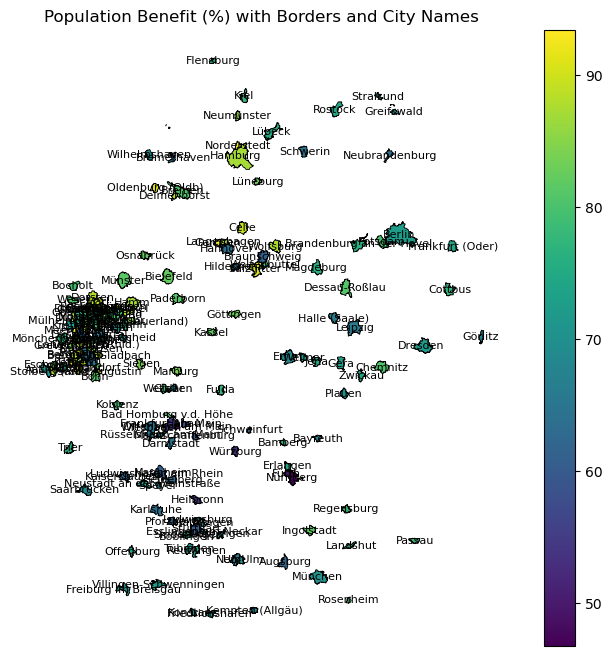

In [23]:
# add city names
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    column="Pop_Benefit_Percent",
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none"
)

gdf.boundary.plot(ax=ax, linewidth=0.6, color="black")

# Add labels
label_points = gdf.geometry.representative_point()

for x, y, name in zip(label_points.x, label_points.y, gdf["GEN"]):
    ax.text(x, y, name, fontsize=8, ha="center", va="center")

ax.set_title("Population Benefit (%) with Borders and City Names")
ax.set_axis_off()

plt.show()


# Overall takeaway
These steps demonstrate how a simple map can be gradually refined into a more informative and visually effective visualisation. By adding context, reducing clutter, and improving readability, we move from basic data display toward clear and meaningful communication of spatial patterns.

In the next chapter, we will learn advanced visualistions for better understanding. 